# Mengukur Jarak Data

Mengukuran jarak data (Similarity dan Dissimilarity) adalah proses untuk menentukan seberapa mirip atau berbeda dua data atau lebih. Jarak ini dapat digunakan dalam berbagai algoritma pembelajaran mesin, seperti clustering, klasifikasi, dan regresi. Dalam mengukur jarak data terdapat beberapa tipe atribut seperti:

- Numerik
- Binary
- Categorical
- Ordinal

## Mengukur Jarak Data (Tipe Numerik)

Salah satu tantangan dalam era ini adalah database yang memiliki banyak tipe data. Mengukur jarak adalah komponen utama dalam algoritma *clustering* berbasis jarak. Algoritma *partitioning* seperti **K-Means**, **K-Medoids**, **Fuzzy C-Means**, dan **Rough Clustering** sangat bergantung pada perhitungan jarak untuk melakukan pengelompokkan data.

Misalkan terdapat dua buah vektor $v_1$ dan $v_2$ dalam ruang dimensi $n$:
$v_1 = (x_1, x_2, \dots, x_n)$
$v_2 = (y_1, y_2, \dots, y_n)$

Berikut adalah beberapa ukuran jarak untuk data tipe numerik:

### 1. Minkowski Distance
Merupakan generalisasi dari jarak Euclidean dan Manhattan.
$$d_{min} = \left( \sum_{i=1}^{n} |x_i - y_i|^m \right)^{1/m}, m \geq 1$$

### 2. Manhattan Distance
Merupakan kasus khusus dari Minkowski Distance pada $m = 1$. Jarak ini sensitif terhadap *outlier*.
$$d_{man} = \sum_{i=1}^{n} |x_i - y_i|$$

### 3. Euclidean Distance
Jarak yang paling terkenal untuk data numerik (kasus khusus Minkowski pada $m = 2$). Sangat umum digunakan namun memiliki kelemahan jika fitur memiliki skala yang berbeda jauh (perlu normalisasi).
$$d_{euc} = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

### 4. Average Distance
Versi modifikasi dari Euclidean untuk memperbaiki hasil dengan menghitung rata-rata.
$$d_{ave} = \left( \frac{1}{n} \sum_{i=1}^{n} (x_i - y_i)^2 \right)^{1/2}$$

### 5. Weighted Euclidean Distance
Digunakan jika setiap atribut memiliki tingkat kepentingan (bobot) yang berbeda.
$$d_{we} = \left( \sum_{i=1}^{n} w_i (x_i - y_i)^2 \right)^{1/2}$$

### 6. Chord Distance
Modifikasi Euclidean untuk mengatasi kekurangan pada data yang tidak dinormalisasi.
$$d_{chord} = \left( 2 - 2 \frac{\sum_{i=1}^{n} x_i y_i}{\|x\|_2 \|y\|_2} \right)^{1/2}$$

### 7. Mahalanobis Distance
Mengukur jarak yang memperhitungkan korelasi antar fitur menggunakan matriks kovarians ($S$).
$$d_{mah} = \sqrt{(x - y) S^{-1} (x - y)^T}$$

### 8. Cosine Similarity
Banyak digunakan untuk kemiripan dokumen (teks).
$$Cosine(x, y) = \frac{\sum_{i=1}^{n} x_i y_i}{\|x\|_2 \|y\|_2}$$

### 9. Pearson Correlation
Menghitung kemiripan antara dua pola (sering digunakan pada ekspresi gen).
$$Pearson(x, y) = \frac{\sum_{i=1}^{n} (x_i - \mu_x)(y_i - \mu_y)}{\sqrt{\sum_{i=1}^{n} (x_i - \mu_x)^2} \sqrt{\sum_{i=1}^{n} (y_i - \mu_y)^2}}$$

## Mengukur Jarak Atribut Binary
Atribut biner hanya memiliki dua status (0 dan 1). Perhitungannya menggunakan tabel kontingensi $2 \times 2$.
Misalkan:
- $q$: jumlah atribut yang bernilai 1 untuk kedua objek.
- $r$: jumlah atribut yang bernilai 1 untuk objek $i$ tapi 0 untuk objek $j$.
- $s$: jumlah atribut yang bernilai 0 untuk objek $i$ tapi 1 untuk objek $j$.
- $t$: jumlah atribut yang bernilai 0 untuk kedua objek.

### 1. Simetris Biner (Symmetric Binary)
Digunakan jika nilai 0 dan 1 dianggap sama pentingnya (misal: jenis kelamin).
$$d(i, j) = \frac{r + s}{q + r + s + t}$$

### 2. Asimetris Biner (Asymmetric Binary)
Digunakan jika hasil positif (1) lebih signifikan (misal: hasil tes penyakit). Nilai $t$ diabaikan.
$$d(i, j) = \frac{r + s}{q + r + s}$$
*Persamaan kemiripannya disebut **Jaccard Coefficient**:*
$$sim(i, j) = \frac{q}{q + r + s}$$

---

## Mengukur Jarak Tipe Categorical (Nominal)
Digunakan untuk atribut yang tidak memiliki urutan (misal: warna, profesi).

### 1. Overlay Metric (OM)
Ukuran paling sederhana, memberikan nilai 0 jika sama dan 1 jika berbeda.
$$d(x, y) = \sum_{i=1}^{n} \delta(a_i(x), a_i(y))$$
Di mana $\delta(a_i(x), a_i(y)) = 0$ jika nilai atribut sama, dan $1$ jika berbeda.

### 2. Value Difference Metric (VDM)
Mengasumsikan dua nilai atribut lebih dekat jika memiliki klasifikasi kelas ($C$) yang sama.
$$d(x, y) = \sum_{i=1}^{n} \sum_{c=1}^{C} |P(c|a_i(x)) - P(c|a_i(y))|$$

---

## Mengukur Jarak Tipe Ordinal
Atribut ordinal memiliki urutan (misal: kecil, sedang, besar). Prosedur penghitungannya adalah:
1. Ganti nilai atribut dengan peringkatnya ($r_{if} \in \{1, \dots, M_f\}$).
2. Lakukan normalisasi nilai ke rentang $[0, 1]$ agar memiliki bobot yang sama dengan tipe data lain:
$$z_{if} = \frac{r_{if} - 1}{M_f - 1}$$
3. Hitung jarak menggunakan ukuran numerik seperti **Euclidean** atau **Manhattan** pada nilai $z_{if}$ tersebut.

---

## Mengukur Jarak Tipe Campuran (Mixed Types)
Untuk database yang memiliki berbagai tipe data (numerik, biner, nominal, ordinal), digunakan **Gower’s Similarity Coefficient**:

$$d(i, j) = \frac{\sum_{f=1}^{p} \delta_{ij}^{(f)} d_{ij}^{(f)}}{\sum_{f=1}^{p} \delta_{ij}^{(f)}}$$

Keterangan:
- $\delta_{ij}^{(f)}$ adalah indikator (bernilai 0 jika data pada atribut $f$ hilang, atau jika atribut bersifat asimetris biner dan keduanya bernilai 0; selain itu bernilai 1).
- $d_{ij}^{(f)}$ adalah kontribusi jarak atribut ke-$f$:
  - Jika **Numerik/Ordinal**: $d_{ij}^{(f)} = \frac{|x_{if} - x_{jf}|}{R_f}$ (di mana $R_f$ adalah rentang nilai maksimum-minimum).
  - Jika **Biner/Nominal**: $d_{ij}^{(f)} = 0$ jika $x_{if} = x_{jf}$, dan $1$ jika sebaliknya.

# Implementasi Menghitung Jarak

## Dataset IRIS

In [ ]:
import pandas as pd

iris = pd.read_csv('dataset/IRIS.csv')

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [64]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


### Tabel Klasifikasi Tipe Data Dataset Iris

| Nama Kolom | Jenis Variabel (Statistik) | Tipe Data (Pandas) | Deskripsi Data |
| :--- | :--- | :--- | :--- |
| **sepal_length** | **Numerik (Kontinu)** | `float64` | Panjang kelopak bunga dalam satuan cm. |
| **sepal_width** | **Numerik (Kontinu)** | `float64` | Lebar kelopak bunga dalam satuan cm. |
| **petal_length** | **Numerik (Kontinu)** | `float64` | Panjang mahkota bunga dalam satuan cm. |
| **petal_width** | **Numerik (Kontinu)** | `float64` | Lebar mahkota bunga dalam satuan cm. |
| **species** | **Kategorikal (Nominal)** | `object` / `str` | Jenis spesies bunga (Setosa, Versicolor, Virginica). |

---

### Ringkasan Dataset
* **Total Sampel:** 150 data.
* **Kualitas Data:** Sangat baik (100% Non-Null), tidak ditemukan data kosong pada semua kolom.
* **Karakteristik:** Dominan numerik, sangat cocok untuk algoritma perhitungan jarak seperti *Euclidean* atau *Manhattan*.

## Dataset Titanic (Campuran)

In [66]:
import pandas as pd

ttc = pd.read_csv("dataset/Titanic-Dataset.csv")

ttc.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [67]:
ttc.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Tabel Klasifikasi Tipe Data Dataset Titanic

| Nama Kolom | Jenis Variabel (Statistik) | Tipe Data (Pandas) | Deskripsi Data |
| :--- | :--- | :--- | :--- |
| **PassengerId** | **Numerik (Diskrit)** | `int64` | Identitas unik/ID setiap penumpang. |
| **Survived** | **Binary** | `int64` | Status keselamatan: **0** (Meninggal), **1** (Selamat). |
| **Pclass** | **Ordinal** | `int64` | Kelas tiket: **1** (Atas), **2** (Menengah), **3** (Bawah). |
| **Name** | **Kategorikal (Nominal)** | `object` / `str` | Nama lengkap penumpang. |
| **Sex** | **Binary** | `object` / `str` | Jenis kelamin: *male* atau *female*. |
| **Age** | **Numerik (Kontinu)** | `float64` | Usia penumpang (memiliki nilai desimal). |
| **SibSp** | **Numerik (Diskrit)** | `int64` | Jumlah saudara/pasangan di kapal. |
| **Parch** | **Numerik (Diskrit)** | `int64` | Jumlah orang tua/anak di kapal. |
| **Ticket** | **Kategorikal (Nominal)** | `object` / `str` | Nomor atau kode tiket penumpang. |
| **Fare** | **Numerik (Kontinu)** | `float64` | Harga/tarif tiket yang dibayar. |
| **Cabin** | **Kategorikal (Nominal)** | `object` / `str` | Nomor kabin (banyak nilai kosong/NaN). |
| **Embarked** | **Kategorikal (Nominal)** | `object` / `str` | Pelabuhan keberangkatan: **C**, **Q**, atau **S**. |
| **Sex_Binary** | **Binary (Numerik)** | `int64` | Hasil transformasi jenis kelamin menjadi angka (0/1). |

---

### Ringkasan Statistik
* **Total Data:** 891 baris.
* **Data Campuran:** Terdiri dari angka (Numerik) dan teks (Kategorikal).
* **Missing Values:** Terdapat data kosong pada kolom `Age`, `Cabin`, dan `Embarked`.

## Tipe Numerik

1. **Import Library**<br>
Langkah pertama adalah menyiapkan alat-alat yang diperlukan. Kita menggunakan pandas untuk olah data, numpy dan scipy untuk perhitungan saintifik, serta math untuk fungsi matematika dasar.

In [50]:
import pandas as pd
import numpy as np
from scipy.spatial import distance
from math import sqrt

2. **Memuat Dataset**<br>
Di sini kita membaca file IRIS.csv. Pastikan file tersebut berada di folder yang sama dengan file notebook Anda agar data dapat diproses oleh sistem.

In [51]:
df = pd.read_csv('dataset/IRIS.csv')

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


3. **Memilih Baris dan Kolom Pembanding**<br>Setelah dataset berhasil dimuat, langkah selanjutnya adalah memilih data yang akan dihitung jaraknya. Kita mengambil dua baris pertama sebagai sampel (sebagai titik $A$ dan titik $B$). Karena kolom ke-5 pada dataset Iris biasanya berisi label teks (spesies), kita hanya melakukan slicing pada kolom indeks 0 sampai 3 agar hanya fitur numerik yang diproses.

In [53]:
# Mengambil dua baris pertama (baris ke-0 dan baris ke-1)
data_pertama = df.iloc[0]
data_kedua   = df.iloc[1]

num_pertama = data_pertama.iloc[0:4].values.astype(float)
num_kedua   = data_kedua.iloc[0:4].values.astype(float)

print("Vektor 1 (Fitur Numerik) :", num_pertama)
print("Vektor 2 (Fitur Numerik) :", num_kedua)

Vektor 1 (Fitur Numerik) : [5.1 3.5 1.4 0.2]
Vektor 2 (Fitur Numerik) : [4.9 3.  1.4 0.2]


### Euclidean Distance

**Euclidean Distance** mengukur jarak garis lurus antara dua titik dalam ruang $n$-dimensi. Rumus matematisnya didefinisikan sebagai:

$$d_{euc} = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

Berikut adalah implementasi menggunakan library **Scipy**, **Numpy**, perhitungan **manual** serta Tools Orange Data Mining:

In [54]:
# 1. Menggunakan Scipy
euc_scipy = distance.euclidean(num_pertama, num_kedua)

# 2. Menggunakan Numpy
euc_numpy = np.linalg.norm(num_pertama - num_kedua)

# 3. Menggunakan Manual
euc_manual = sqrt(sum((x - y) ** 2 for x, y in zip(num_pertama, num_kedua)))

print("HASIL EUCLIDEAN DISTANCE")
print(f"Scipy  : {euc_scipy:.3f}")
print(f"Numpy  : {euc_numpy:.3f}")
print(f"Manual : {euc_manual:.3f}")

HASIL EUCLIDEAN DISTANCE
Scipy  : 0.539
Numpy  : 0.539
Manual : 0.539


Berikut adalah hasil dari Orange Data Mining:

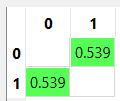

### **Manhattan Distance**
**Manhattan Distance** (sering disebut *City Block Distance*) mengukur jarak dengan menjumlahkan nilai absolut dari selisih setiap koordinatnya. Rumus matematisnya adalah:

$$d_{man} = \sum_{i=1}^{n} |x_i - y_i|$$
Berikut adalah implementasi menggunakan library **Scipy**, **Numpy**, perhitungan **manual** serta Tools Orange Data Mining:

In [55]:
# 1. Menggunakan Scipy
man_scipy = distance.cityblock(num_pertama, num_kedua)

# 2. Menggunakan Numpy
man_numpy = np.sum(np.abs(num_pertama - num_kedua))

# 3. Menggunakan Manual
man_manual = sum(abs((x - y)) for x, y in zip(num_pertama, num_kedua))

print("HASIL MANHATTAN DISTANCE")
print(f"Scipy  : {man_scipy:.3f}")
print(f"Numpy  : {man_numpy:.3f}")
print(f"Manual : {man_manual:.3f}")

HASIL MANHATTAN DISTANCE
Scipy  : 0.700
Numpy  : 0.700
Manual : 0.700


Berikut adalah hasil dari Orange Data Mining:

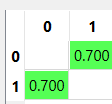

## Tipe Binary

1. **Import Library**<br>
Langkah awal adalah memuat pustaka yang dibutuhkan. Selain pustaka standar, kita membutuhkan scipy untuk fungsi jarak biner bawaan.



In [56]:
import pandas as pd
import numpy as np
from scipy.spatial import distance

2. **Memuat Dataset Titanic**<br>
Kita akan menggunakan dataset Titanic. Dataset ini sangat cocok karena memiliki kombinasi fitur biner, kategori, dan numerik.

In [57]:
# Membaca dataset Titanic dari sumber publik
df = pd.read_csv("dataset/Titanic-Dataset.csv")

# Menampilkan 5 data teratas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3. **Preprocessing dan Pemilihan Kolom**<br>
Agar data dapat dihitung jaraknya, kita perlu mengubah kolom kategori menjadi biner dan membersihkan nilai yang kosong (missing values).

Pada tahap ini, kita melakukan:
1. Mengubah fitur **Sex** menjadi biner (0 untuk female, 1 untuk male).
2. Memilih kolom **Survived** sebagai fitur biner asimetris.
3. Memilih kolom **Pclass** dan **Age** untuk fitur campuran.
4. Menghapus baris dengan nilai kosong agar perhitungan tidak error.

In [10]:
# Mapping data kategori ke biner
df['Sex_Binary'] = df['Sex'].map({'male': 1, 'female': 0})

# Membersihkan data
df_clean = df[['Survived', 'Sex_Binary', 'Pclass', 'Age']].dropna().reset_index(drop=True)

# Mengambil dua baris sebagai sampel pembanding
data_1 = df_clean.iloc[0]
data_2 = df_clean.iloc[1]

print("Data Pembanding 1:\n", data_1)
print("\nData Pembanding 2:\n", data_2)

Data Pembanding 1:
 Survived       0.0
Sex_Binary     1.0
Pclass         3.0
Age           22.0
Name: 0, dtype: float64

Data Pembanding 2:
 Survived       1.0
Sex_Binary     0.0
Pclass         1.0
Age           38.0
Name: 1, dtype: float64


### Biner Simetris (SMC)

Atribut simetris menganggap nilai $0$ dan $1$ sama pentingnya. Rumus Simple Matching Coefficient (SMC) adalah:

$$d(i, j) = \frac{r + s}{q + r + s + t}$$



In [11]:
# Mengambil kolom Sex_Binary saja
v1_sim = np.array([data_1['Sex_Binary']])
v2_sim = np.array([data_2['Sex_Binary']])

# Implementasi manual SMC
def hitung_smc(v1, v2):
    m11 = np.sum((v1 == 1) & (v2 == 1))
    m00 = np.sum((v1 == 0) & (v2 == 0))
    total = len(v1)
    return (m11 + m00) / total

print(f"Hasil SMC (Simetris): {hitung_smc(v1_sim, v2_sim):.3f}")

Hasil SMC (Simetris): 0.000


### Biner Asimetris (Jaccard)

Pada biner asimetris, nilai $1$ dianggap lebih bermakna daripada $0$. Berikut adalah rumus:
$$d(i, j) = \frac{r + s}{q + r + s}$$
*Persamaan kemiripannya disebut **Jaccard Coefficient**:*
$$sim(i, j) = \frac{q}{q + r + s}$$


In [12]:
# Mengambil kolom Survived sebagai sampel asimetris
v1_asym = np.array([data_1['Survived']])
v2_asym = np.array([data_2['Survived']])

# Menggunakan fungsi bawaan scipy (Distance = 1 - Similarity)
jaccard_dist = distance.jaccard(v1_asym, v2_asym)
jaccard_sim = 1 - jaccard_dist

print(f"Jaccard Similarity (Asimetris): {jaccard_sim:.3f}")
print(f"Jaccard Distance: {jaccard_dist:.3f}")

Jaccard Similarity (Asimetris): 0.000
Jaccard Distance: 1.000


Berikut ada hasil dari Orange Data Mining:

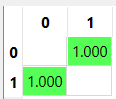

### Biner Campuran (Mixed Attributes)

Untuk data campuran, kita menghitung jarak tiap fitur secara terpisah (berdasarkan tipenya) lalu merata-ratakannya. Untuk fitur numerik seperti Age, kita menggunakan normalisasi rentang (range).

$$d(i,j) = \frac{\sum dist\_fitur}{total\_fitur}$$

In [13]:
# Menentukan rentang untuk normalisasi Age
age_range = df_clean['Age'].max() - df_clean['Age'].min()

def hitung_campuran(p1, p2):
    # Jarak Numerik (Age) - Dinormalisasi
    d_age = abs(p1['Age'] - p2['Age']) / age_range

    # Jarak Biner (Sex) - Simetris
    d_sex = 0 if p1['Sex_Binary'] == p2['Sex_Binary'] else 1

    # Jarak Nominal (Pclass)
    d_pclass = 0 if p1['Pclass'] == p2['Pclass'] else 1

    # Rata-rata
    return (d_age + d_sex + d_pclass) / 3

hasil_campuran = hitung_campuran(data_1, data_2)
print(f"Jarak Campuran (Gower-based): {hasil_campuran:.3f}")

Jarak Campuran (Gower-based): 0.734


## Tipe Categorical

1. **Import Library**<br>
Langkah awal untuk memproses data kategorikal.



In [14]:
import pandas as pd
import numpy as np

2. **Memuat Dataset (Categorical Fokus)**<br>
Kita akan menggunakan dataset Titanic lagi, namun kali ini kita fokus pada kolom-kolom kategori seperti Embarked (Pelabuhan Keberangkatan), Sex, dan Pclass.

In [15]:
# Membaca dataset Titanic dari sumber publik
df_cat = pd.read_csv("dataset/Titanic-Dataset.csv")

# Menampilkan 5 data teratas
df_cat = df_cat[['Sex', 'Embarked', 'Pclass']].dropna().reset_index(drop=True)

# Menampilkan 5 data teratas
df_cat.head()

,Sex,Embarked,Pclass
0,male,S,3
1,female,C,1
2,female,S,3
3,female,S,1
4,male,S,3


3. **Memilih Data Pembanding (Categorical)**<br>
Kita akan mengambil dua baris data untuk dibandingkan kecocokan kategorinya.

In [16]:
# Mengambil dua baris sebagai sampel
cat_1 = df_cat.iloc[0] # Contoh: Male, S, 3
cat_2 = df_cat.iloc[2] # Contoh: Female, S, 3

print("Data Kategori 1:\n", cat_1)
print("-" * 30)
print("Data Kategori 2:\n", cat_2)

Data Kategori 1:
 Sex         male
Embarked       S
Pclass         3
Name: 0, dtype: object
------------------------------
Data Kategori 2:
 Sex         female
Embarked         S
Pclass           3
Name: 2, dtype: object


### Overlay Metric (OM)

Overlay Metric memberikan nilai $0$ jika nilai atribut sama, dan $1$ jika berbeda. Jarak total adalah jumlah ketidakcocokan dibagi dengan total atribut. Rumus matematis: $$d(x,y) = \sum_{i=1}^{n} \delta(a_i(x), a_i(y))$$

Di mana:
$$\delta(a_i(x), a_i(y)) =
\begin{cases}
0, & \text{jika } a_i(x) = a_i(y) \
1, & \text{jika } a_i(x) \neq a_i(y)
\end{cases}$$

In [17]:
def overlay_metric(p1, p2):
    # Menghitung delta: 0 jika sama, 1 jika beda
    delta = [0 if a == b else 1 for a, b in zip(p1, p2)]

    total_jarak = sum(delta)
    # Normalisasi jarak (0 sampai 1)
    jarak_normalisasi = total_jarak / len(p1)

    return total_jarak, jarak_normalisasi

jarak_om, jarak_norm = overlay_metric(cat_1, cat_2)

print(f"Detail Ketidakcocokan: {[1 if a != b else 0 for a, b in zip(cat_1, cat_2)]}")
print(f"Total Jarak (OM)        : {jarak_om}")
print(f"Jarak Normalisasi (0-1) : {jarak_norm:.4f}")

Detail Ketidakcocokan: [1, 0, 0]
Total Jarak (OM)        : 1
Jarak Normalisasi (0-1) : 0.3333


## Tipe Ordinal

1. **Import Library**<br>
Langkah awal untuk memproses data ordinal dan perhitungan numerik.

In [18]:
import pandas as pd
import numpy as np

2. **Memuat Dataset (Fokus Ordinal)**<br>
Kita akan menggunakan dataset Titanic dengan fokus pada kolom Pclass (Ticket Class). Kolom ini adalah data ordinal karena memiliki tingkatan (1st > 2nd > 3rd).

In [19]:
# Membaca dataset Titanic dari sumber publik
df_ord = pd.read_csv("dataset/Titanic-Dataset.csv")

# Memilih kolom Pclass sebagai data ordinal
df_ord = df_ord[['Pclass']].dropna().reset_index(drop=True)

# Menampilkan data unik untuk melihat tingkatan (M_f)
print("Daftar Peringkat Pclass:", sorted(df_ord['Pclass'].unique()))

Daftar Peringkat Pclass: [np.int64(1), np.int64(2), np.int64(3)]


3. **Transformasi dan Normalisasi Ordinal**<br>
Untuk menghitung jarak, kita harus mengubah peringkat ($r_{if}$) menjadi nilai terstandarisasi ($z_{if}$) menggunakan rumus:
$$z_{if} = \frac{r_{if} - 1}{M_f - 1}$$
Di mana $M_f$ adalah jumlah total peringkat dalam atribut tersebut (untuk Pclass, $M_f = 3$).

In [20]:
# Menentukan nilai peringkat maksimum (M_f)
M_f = df_ord['Pclass'].max()

# Melakukan normalisasi ke rentang [0, 1]
df_ord['z_if'] = (df_ord['Pclass'] - 1) / (M_f - 1)

# Mengambil dua baris sebagai sampel pembanding
ord_1 = df_ord.iloc[0] # Pclass 3
ord_2 = df_ord.iloc[1] # Pclass 1

print("Data 1 (Asli):", ord_1['Pclass'], " -> Hasil z_if:", ord_1['z_if'])
print("Data 2 (Asli):", ord_2['Pclass'], " -> Hasil z_if:", ord_2['z_if'])

Data 1 (Asli): 3.0  -> Hasil z_if: 1.0
Data 2 (Asli): 1.0  -> Hasil z_if: 0.0


4. **Transformasi dan Normalisasi Ordinal**<br>
Setelah nilai dikonversi ke $z_{if}$, kita bisa menghitung jaraknya menggunakan metrik numerik seperti Manhattan Distance.
$$d(x,y) = |z_{i1} - z_{i2}|$$

In [21]:
# Menghitung jarak absolut (Manhattan) antara dua nilai z_if
jarak_ordinal = abs(ord_1['z_if'] - ord_2['z_if'])

print(f"Jarak Ordinal antara Pclass {int(ord_1['Pclass'])} dan {int(ord_2['Pclass'])} adalah: {jarak_ordinal:.4f}")

Jarak Ordinal antara Pclass 3 dan 1 adalah: 1.0000


## Tipe Campuran

1. **Import Library**<br>
Langkah awal untuk memproses data campuran dan perhitungan jarak.

In [26]:
import seaborn as sns
import pandas as pd
import gower
import matplotlib.pyplot as plt

2. **Memuat Dataset Titanic**


In [27]:
# Membaca dataset Titanic dari sumber publik
df = pd.read_csv("dataset/Titanic-Dataset.csv")

# Menampilkan 5 data teratas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3. **Memilih Data Pembanding (Campuran)**<br>
Kita akan mengambil dua baris data untuk dibandingkan dengan mempertimbangkan semua jenis atribut (numerik, biner, dan kategori).

In [48]:
df_clean = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_gower = df_clean.astype(object)
df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [49]:
# Membuat ringkasan tipe data dalam bentuk tabel
type_summary = df_clean.dtypes.reset_index()
type_summary.columns = ['Kolom', 'Tipe Data']

print("Tabel Tipe Data df_clean:")
print(type_summary)

Tabel Tipe Data df_clean:
      Kolom Tipe Data
0  Survived     int64
1    Pclass     int64
2       Sex       str
3       Age   float64
4     SibSp     int64
5     Parch     int64
6      Fare   float64
7  Embarked       str


4. **Menghitung Jarak Campuran (Gower’s Similarity Coefficient)**<br>
Untuk data campuran, kita menggunakan Gower’s Similarity Coefficient yang menghitung jarak tiap fitur berdasarkan tipenya, lalu merata-ratakannya. Rumusnya adalah:
$$d(i, j) = \frac{\sum_{f=1}^{p} \delta_{ij}^{(f)} d_{ij}^{(f)}}{\sum_{f=1}^{p} \delta_{ij}^{(f)}}$$

In [46]:
distance_matrix = gower.gower_matrix(df_gower)
# 5. Buat DataFrame Matriks Jarak
dist_df = pd.DataFrame(
    distance_matrix, 
    index=df_gower.index,
    columns=df_gower.index
)

# Menampilkan 5x5 pertama dari matriks
print("Matriks Jarak (5 Baris Pertama):")
print(dist_df.iloc[:5, :5].round(3))

Matriks Jarak (5 Baris Pertama):
       0      1      2      3      4
0  0.000  0.750  0.625  0.625  0.375
1  0.750  0.000  0.625  0.375  0.875
2  0.625  0.625  0.000  0.500  0.500
3  0.625  0.375  0.500  0.000  0.625
4  0.375  0.875  0.500  0.625  0.000
